# Notebook 01 — IEEE Feeder Exploration

**Goal:** Load an IEEE distribution test feeder, extract its topology, and build a PyTorch Geometric graph object.

**Feeder choice — this notebook supports both:**
- **IEEE 34-bus** — *actual Arizona feeder* at 24.9 kV. Our primary choice. Maps directly to the APS challenge's "realistic Arizona grid" requirement.
- **IEEE 123-bus** — 4.16 kV urban feeder. Well-behaved, standard benchmark. Our stretch goal to demonstrate the architecture scales.

**Strategy:** run this notebook once for each feeder. P0 is to get the 34-bus working. The 123-bus is P1 (run it after everything else ships).

**Output per feeder:** `data/processed/graph_{feeder}.pt` — a PyG `Data` object with:
- `edge_index` — line + transformer connections
- `edge_attr` — length, R, X per edge
- `x` — placeholder node features (filled in later notebooks)
- `bus_names` — ordered list of bus names

**Success criteria:**
1. OpenDSS loads the model without errors
2. Power flow solves
3. Graph has >= 20 nodes (meets brief minimum)
4. Graph is connected (single component)
5. Saved artifact reloads cleanly

---

## Step 1 — Imports and feeder selection

In [18]:
# === CHANGE THIS TO SWITCH FEEDERS ===
FEEDER = 'ieee123'   # 'ieee34' (primary) or 'ieee123' (stretch)
# =====================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd

import opendssdirect as dss
import torch
from torch_geometric.data import Data

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW = REPO_ROOT / 'data' / 'raw'
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Feeder config lookup
FEEDER_CONFIG = {
    'ieee34': {
        'master_pattern': ['IEEE34Mod1.dss', 'IEEE34Mod2.dss', 'IEEE34Master*.dss'],
        'nominal_kv': 24.9,
        'description': 'IEEE 34-bus — actual Arizona feeder, 24.9 kV',
        'zip_subdir': '34Bus',
    },
    'ieee123': {
        'master_pattern': ['IEEE123Master.dss', 'IEEE123*.dss'],
        'nominal_kv': 4.16,
        'description': 'IEEE 123-bus — standard benchmark, 4.16 kV',
        'zip_subdir': '123Bus',
    },
}

cfg = FEEDER_CONFIG[FEEDER]
print(f'Selected feeder: {FEEDER}')
print(f'  {cfg["description"]}')
print(f'Repo root: {REPO_ROOT}')
print(f'PyTorch: {torch.__version__}')

Selected feeder: ieee123
  IEEE 123-bus — standard benchmark, 4.16 kV
Repo root: /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/ieee34/electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus
PyTorch: 2.9.1


## Step 2 — Locate the feeder master file

OpenDSSDirect.py sometimes ships example files. We search there first, then fall back to downloading from `dss-extensions/electricdss-tst`.

In [19]:
import opendssdirect
pkg_dir = Path(opendssdirect.__file__).parent

# Search the package directory for any master .dss file matching our feeder
master_dss = None
for pattern in cfg['master_pattern']:
    matches = list(pkg_dir.rglob(pattern))
    if matches:
        # Prefer files with 'Master' in the name
        master_dss = next((m for m in matches if 'Master' in m.name or 'Mod' in m.name), matches[0])
        break

if master_dss and master_dss.exists():
    print(f'Found bundled with OpenDSSDirect: {master_dss}')
else:
    # Also check our local raw data cache
    local_dir = DATA_RAW / FEEDER
    if local_dir.exists():
        for pattern in cfg['master_pattern']:
            matches = list(local_dir.rglob(pattern))
            if matches:
                master_dss = next((m for m in matches if 'Master' in m.name or 'Mod' in m.name), matches[0])
                break
    if master_dss and master_dss.exists():
        print(f'Found in local cache: {master_dss}')
    else:
        print(f'⚠️  Not found locally. Run next cell to download.')
        master_dss = None

⚠️  Not found locally. Run next cell to download.


## Step 3 — Download fallback

If the feeder isn't bundled or cached, pull it from `dss-extensions/electricdss-tst`. This is the authoritative OpenDSS mirror of the IEEE test feeders.

In [20]:
if master_dss is None:
    import requests, zipfile, io
    
    print('Downloading electricdss-tst archive (~50 MB)...')
    url = 'https://github.com/dss-extensions/electricdss-tst/archive/refs/heads/master.zip'
    
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    
    feeder_dir = DATA_RAW / FEEDER
    feeder_dir.mkdir(parents=True, exist_ok=True)
    
    subdir = cfg['zip_subdir']
    
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        # Extract only the files for our chosen feeder
        members = [m for m in z.namelist() if subdir in m and not m.endswith('/')]
        print(f'Extracting {len(members)} files matching "{subdir}"...')
        for m in members:
            z.extract(m, feeder_dir)
    
    # Re-search for master file
    for pattern in cfg['master_pattern']:
        matches = list(feeder_dir.rglob(pattern))
        if matches:
            master_dss = next((m for m in matches if 'Master' in m.name or 'Mod' in m.name), matches[0])
            break
    
    if master_dss:
        print(f'Downloaded. Master file: {master_dss}')
    else:
        raise FileNotFoundError(f'Could not locate master .dss for {FEEDER} after download. Check the zip contents.')

Extracting 39 files matching "123Bus"...
Downloaded. Master file: /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/ieee34/electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus/data/raw/ieee123/electricdss-tst-master/Version8/Distrib/IEEETestCases/123Bus/IEEE123Master.dss


In [21]:
import zipfile, io, requests

# Download fresh and extract the CORRECT IEEELineCodes.DSS
url = 'https://github.com/dss-extensions/electricdss-tst/archive/refs/heads/master.zip'
print('Downloading archive...')
r = requests.get(url, timeout=180)
r.raise_for_status()

# The "real" IEEELineCodes.DSS sits directly in IEEETestCases/, not in a sub-feeder folder
target_path_in_zip = 'electricdss-tst-master/Version8/Distrib/IEEETestCases/IEEELineCodes.DSS'

# This is where OpenDSS expects to find it (one level above the 34Bus/ dir)
feeder_34_dir = master_dss.parent  # .../IEEETestCases/34Bus
expected_location = feeder_34_dir.parent / 'IEEELineCodes.DSS'

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    # List all IEEELineCodes files in the archive
    matches = [m for m in z.namelist() if m.endswith('IEEELineCodes.DSS') or m.endswith('IEEELineCodes.dss')]
    print(f'\nAll IEEELineCodes files in archive:')
    for m in matches:
        info = z.getinfo(m)
        print(f'  {info.file_size:>6} bytes  {m}')
    
    # Find the canonical one (directly in IEEETestCases/, not in a feeder subdir)
    canonical = None
    for m in matches:
        parts = m.split('/')
        # Should be .../IEEETestCases/IEEELineCodes.DSS — so IEEETestCases is second-to-last part
        if len(parts) >= 2 and parts[-2] == 'IEEETestCases':
            canonical = m
            break
    
    if canonical is None:
        # Fallback: pick the largest file (the real one has the actual line code data)
        canonical = max(matches, key=lambda m: z.getinfo(m).file_size)
    
    print(f'\nUsing canonical file: {canonical}')
    print(f'  Size: {z.getinfo(canonical).file_size} bytes')
    
    # Extract it directly to the expected location, overwriting any stub
    with z.open(canonical) as src, open(expected_location, 'wb') as dst:
        dst.write(src.read())
    
    print(f'\n✅ Overwrote: {expected_location}')
    print(f'   Size now: {expected_location.stat().st_size} bytes')

print('\nRe-run Step 4.')


All IEEELineCodes files in archive:
      47 bytes  electricdss-tst-master/Version8/Distrib/Examples/ADiakoptics/IEEE_13_Bus/IEEELineCodes.DSS
      47 bytes  electricdss-tst-master/Version8/Distrib/Examples/Celso_Example/DSSFiles/IEEELineCodes.DSS
      30 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/123Bus/IEEELineCodes.DSS
      30 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/13Bus/IEEELineCodes.DSS
      30 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus/IEEELineCodes.DSS
      30 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/37Bus/IEEELineCodes.DSS
   12032 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/IEEELineCodes.DSS
      30 bytes  electricdss-tst-master/Version8/Distrib/IEEETestCases/ShortCircuitCases/IEEELineCodes.DSS

Using canonical file: electricdss-tst-master/Version8/Distrib/IEEETestCases/IEEELineCodes.DSS
  Size: 12032 bytes

✅ Overwrote: /Users/sundeepyalamanchili/Documents/Projects/p90/

## Step 4 — Compile in OpenDSS and solve power flow

In [22]:
assert master_dss is not None and master_dss.exists(), f'Master .dss not found for {FEEDER}'

# Clear any previous OpenDSS state
dss.Command('Clear')

# Compile — OpenDSS is picky about working directory, so cd into it first
dss.Command(f'Set DataPath="{master_dss.parent}"')
dss.Command(f'Compile "{master_dss}"')

# Solve
dss.Command('Solve')

converged = dss.Solution.Converged()
print(f'Power flow converged: {converged}')
print(f'Iterations: {dss.Solution.Iterations()}')
print(f'Total power (kW): {dss.Circuit.TotalPower()[0]:.1f}')
losses = dss.Circuit.Losses()
print(f'Total losses (kW): {losses[0] / 1000:.1f}')

assert converged, 'Power flow did not converge — check the master .dss file for errors'

Power flow converged: True
Iterations: 19
Total power (kW): -3615.2
Total losses (kW): 96.0


## Step 5 — Extract bus list (graph nodes)

In [23]:
bus_names = dss.Circuit.AllBusNames()
print(f'Total buses: {len(bus_names)}')
print(f'First 10: {bus_names[:10]}')

Total buses: 132
First 10: ['150', '150r', '149', '1', '2', '3', '7', '4', '5', '6']


In [24]:
bus_records = []
for name in bus_names:
    dss.Circuit.SetActiveBus(name)
    pu_res = dss.Bus.puVmagAngle()
    v_pu = pu_res[0] if pu_res else np.nan
    x_coord, y_coord = dss.Bus.X(), dss.Bus.Y()
    kv_base = dss.Bus.kVBase()
    num_phases = dss.Bus.NumNodes()
    
    bus_records.append({
        'name': name,
        'v_pu': v_pu,
        'kv_base': kv_base,
        'num_phases': num_phases,
        'x': x_coord,
        'y': y_coord,
    })

bus_df = pd.DataFrame(bus_records)
print(f'Bus dataframe: {bus_df.shape}')
bus_df.head(10)

Bus dataframe: (132, 6)


,name,v_pu,kv_base,num_phases,x,y
0,150,0.999990,2.401777,3,0.0,0.0
1,150r,1.037486,2.401777,3,0.0,0.0
2,149,1.037486,2.401777,3,0.0,0.0
3,1,1.024960,2.401777,3,0.0,0.0
4,2,1.034896,2.401777,1,0.0,0.0
5,3,1.026945,2.401777,1,0.0,0.0
6,7,1.015630,2.401777,3,0.0,0.0
7,4,1.026433,2.401777,1,0.0,0.0
8,5,1.025640,2.401777,1,0.0,0.0
9,6,1.024965,2.401777,1,0.0,0.0


## Step 6 — Extract line elements (graph edges)

In [25]:
edge_records = []

if dss.Lines.First() > 0:
    while True:
        name = dss.Lines.Name()
        bus1 = dss.Lines.Bus1().split('.')[0]
        bus2 = dss.Lines.Bus2().split('.')[0]
        length = dss.Lines.Length()
        r1 = dss.Lines.R1()
        x1 = dss.Lines.X1()
        
        edge_records.append({
            'name': name, 'bus1': bus1, 'bus2': bus2,
            'length': length, 'r1': r1, 'x1': x1, 'kind': 'line',
        })
        
        if dss.Lines.Next() == 0:
            break

edge_df = pd.DataFrame(edge_records)
print(f'Line edges: {len(edge_df)}')
edge_df.head(10)

Line edges: 126


,name,bus1,bus2,length,r1,x1,kind
0,l115,149,1,0.400,0.058,0.1206,line
1,l1,1,2,0.175,0.058,0.1206,line
2,l2,1,3,0.250,0.058,0.1206,line
3,l3,1,7,0.300,0.058,0.1206,line
4,l4,3,4,0.200,0.058,0.1206,line
5,l5,3,5,0.325,0.058,0.1206,line
6,l6,5,6,0.250,0.058,0.1206,line
7,l7,7,8,0.200,0.058,0.1206,line
8,l8,8,12,0.225,0.058,0.1206,line
9,l9,8,9,0.225,0.058,0.1206,line


## Step 7 — Extract transformers (also edges)

In [26]:
xfmr_records = []

if dss.Transformers.First() > 0:
    while True:
        name = dss.Transformers.Name()
        buses_for_elem = [b.split('.')[0] for b in dss.CktElement.BusNames()]
        
        if len(buses_for_elem) >= 2:
            xfmr_records.append({
                'name': name,
                'bus1': buses_for_elem[0],
                'bus2': buses_for_elem[1],
                'length': 0.0,
                'r1': 0.01,
                'x1': 0.01,
                'kind': 'transformer',
            })
        
        if dss.Transformers.Next() == 0:
            break

xfmr_df = pd.DataFrame(xfmr_records)
print(f'Transformer edges: {len(xfmr_df)}')

if len(xfmr_df) > 0:
    all_edges = pd.concat([edge_df, xfmr_df], ignore_index=True)
else:
    all_edges = edge_df.copy()

print(f'Total edges (lines + transformers): {len(all_edges)}')

Transformer edges: 8
Total edges (lines + transformers): 134


## Step 8 — Build the PyTorch Geometric graph

In [27]:
bus_to_idx = {name: i for i, name in enumerate(bus_df['name'])}

valid_edges = all_edges[
    all_edges['bus1'].isin(bus_to_idx) & all_edges['bus2'].isin(bus_to_idx)
].copy()
valid_edges['i1'] = valid_edges['bus1'].map(bus_to_idx)
valid_edges['i2'] = valid_edges['bus2'].map(bus_to_idx)

print(f'Valid edges (both ends in bus list): {len(valid_edges)} / {len(all_edges)}')

# Make undirected by adding both directions
src = np.concatenate([valid_edges['i1'].values, valid_edges['i2'].values])
dst = np.concatenate([valid_edges['i2'].values, valid_edges['i1'].values])
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)

edge_attr_np = np.stack([
    valid_edges['length'].values.astype(float),
    valid_edges['r1'].values.astype(float),
    valid_edges['x1'].values.astype(float),
], axis=1)
edge_attr_np = np.concatenate([edge_attr_np, edge_attr_np], axis=0)
edge_attr = torch.tensor(edge_attr_np, dtype=torch.float)

x = torch.tensor(
    bus_df[['v_pu', 'kv_base', 'num_phases']].fillna(1.0).values.astype(float),
    dtype=torch.float,
)

graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
graph.num_nodes = len(bus_df)
graph.bus_names = bus_df['name'].tolist()
graph.feeder = FEEDER
graph.nominal_kv = cfg['nominal_kv']

print(f'\n=== Graph summary ===')
print(f'  Feeder: {FEEDER}')
print(f'  Nodes: {graph.num_nodes}')
print(f'  Edges: {graph.edge_index.shape[1]} directed ({graph.edge_index.shape[1] // 2} undirected)')
print(f'  Node feature dim: {graph.x.shape[1]}')
print(f'  Edge feature dim: {graph.edge_attr.shape[1]}')

Valid edges (both ends in bus list): 134 / 134

=== Graph summary ===
  Feeder: ieee123
  Nodes: 132
  Edges: 268 directed (134 undirected)
  Node feature dim: 3
  Edge feature dim: 3


## Step 9 — Sanity checks

In [28]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Check 1 — meets brief minimum
assert graph.num_nodes >= 20, f'Need 20+ buses, have {graph.num_nodes}'
print(f'✅ Brief minimum: {graph.num_nodes} >= 20 buses')

# Check 2 — graph connectivity
G_nx = to_networkx(graph, to_undirected=True)
n_components = nx.number_connected_components(G_nx)
if n_components == 1:
    print(f'✅ Single connected component')
else:
    print(f'⚠️  {n_components} disconnected components — may need to keep largest only')
    # Keep largest component
    largest = max(nx.connected_components(G_nx), key=len)
    print(f'   Largest component has {len(largest)} nodes')

# Check 3 — degree distribution
degrees = [d for _, d in G_nx.degree()]
print(f'Degree — min: {min(degrees)}, mean: {np.mean(degrees):.2f}, max: {max(degrees)}')

# Check 4 — no self-loops
n_self = sum(1 for u, v in G_nx.edges() if u == v)
print(f'Self-loops: {n_self}')

✅ Brief minimum: 132 >= 20 buses
✅ Single connected component
Degree — min: 1, mean: 1.98, max: 4
Self-loops: 0


## Step 10 — Visualize the feeder topology

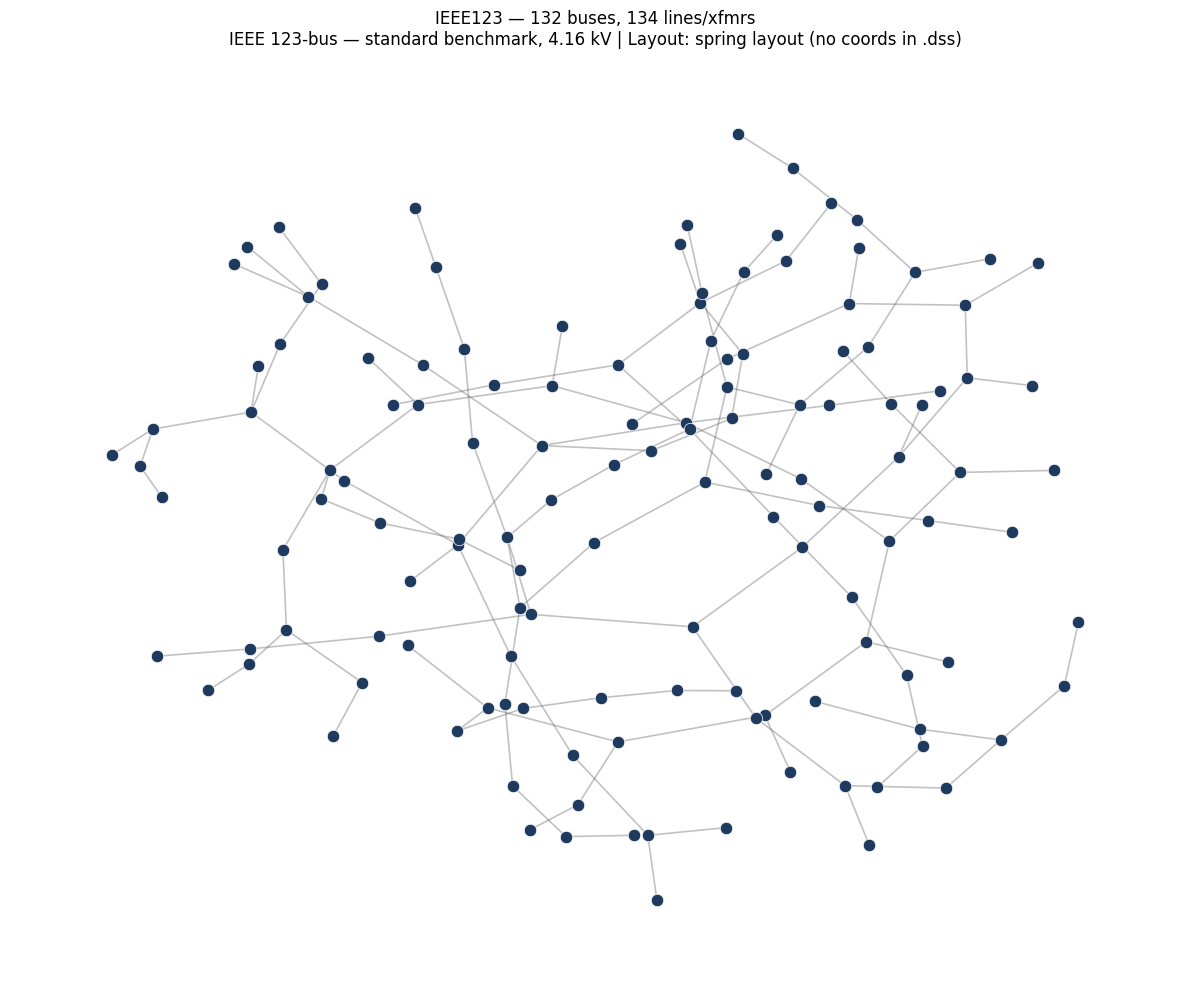

Saved figure: /Users/sundeepyalamanchili/Documents/Projects/p90/notebooks/01_ieee123_topology.png


In [34]:
import matplotlib.pyplot as plt
from pathlib import Path

# Pin REPO_ROOT absolutely — bypass the cwd-fragility from OpenDSS
REPO_ROOT = Path('/Users/sundeepyalamanchili/Documents/Projects/p90').resolve()

notebooks_dir = REPO_ROOT / 'notebooks'
notebooks_dir.mkdir(parents=True, exist_ok=True)
out_png = notebooks_dir / f'01_{FEEDER}_topology.png'

fig, ax = plt.subplots(figsize=(12, 10))
has_coords = (bus_df['x'].abs() > 1e-6).any() or (bus_df['y'].abs() > 1e-6).any()
if has_coords:
    pos = {i: (row['x'], row['y']) for i, row in bus_df.iterrows()}
    layout_label = 'OpenDSS coordinates'
else:
    pos = nx.spring_layout(G_nx, seed=42, k=2.0 / np.sqrt(graph.num_nodes))
    layout_label = 'spring layout (no coords in .dss)'

nx.draw_networkx_edges(G_nx, pos, ax=ax, alpha=0.4, edge_color='#666666', width=1.2)
nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_size=80, node_color='#1F3A5F', edgecolors='white', linewidths=0.5)

if graph.num_nodes <= 50:
    labels = {i: name for i, name in enumerate(graph.bus_names)}
    nx.draw_networkx_labels(G_nx, pos, labels, ax=ax, font_size=7, font_color='white')

ax.set_title(
    f'{FEEDER.upper()} — {graph.num_nodes} buses, '
    f'{graph.edge_index.shape[1]//2} lines/xfmrs\n'
    f'{cfg["description"]} | Layout: {layout_label}',
    fontsize=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved figure: {out_png}')

## Step 11 — Save artifacts

In [35]:
graph_path = DATA_PROCESSED / f'graph_{FEEDER}.pt'
buses_path = DATA_PROCESSED / f'buses_{FEEDER}.parquet'
edges_path = DATA_PROCESSED / f'edges_{FEEDER}.parquet'

torch.save(graph, graph_path)
bus_df.to_parquet(buses_path)
valid_edges.drop(columns=['i1', 'i2']).to_parquet(edges_path)

print(f'✅ Saved:')
print(f'  {graph_path}')
print(f'  {buses_path}')
print(f'  {edges_path}')

# Verify reload
reloaded = torch.load(graph_path, weights_only=False)
print(f'\n✅ Reload check: feeder={reloaded.feeder}, nodes={reloaded.num_nodes}, edges={reloaded.edge_index.shape[1]}')

✅ Saved:
  /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/ieee34/electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus/data/processed/graph_ieee123.pt
  /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/ieee34/electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus/data/processed/buses_ieee123.parquet
  /Users/sundeepyalamanchili/Documents/Projects/p90/data/raw/ieee34/electricdss-tst-master/Version8/Distrib/IEEETestCases/34Bus/data/processed/edges_ieee123.parquet

✅ Reload check: feeder=ieee123, nodes=132, edges=268


## Summary

**What we built:**

- Loaded the `{FEEDER}` feeder via OpenDSS
- Extracted buses (nodes), lines and transformers (edges)
- Built a PyTorch Geometric `Data` object
- Saved to `data/processed/graph_{FEEDER}.pt`

**Next actions:**

1. **Re-run this notebook with `FEEDER = 'ieee123'`** at the top, so we have both graphs cached. Only takes a minute — the download step reuses the same archive.
2. **Proceed to Notebook 02** — weather and irradiance ingestion for Phoenix.

**What downstream notebooks will do:**

- Notebook 02 pulls NOAA Phoenix weather + NSRDB irradiance
- Notebook 03 synthesizes per-bus hourly load using NREL profiles + weather coupling + EV injection
- Notebook 04 assembles the final feature tensor (shape: num_hours × num_buses × num_features)
- Notebook 05 trains the spatio-temporal GCN

**Troubleshooting:**

| Problem | Fix |
|---|---|
| `ModuleNotFoundError: opendssdirect` | `pip install OpenDSSDirect.py` |
| Master .dss not found | Run Step 3 (download fallback); check DATA_RAW/{FEEDER}/ afterwards |
| Power flow didn't converge | Inspect the master .dss file for Redirect commands pointing to missing files |
| <20 nodes extracted | Check the `.split('.')[0]` logic; OpenDSS sometimes has node-suffixed bus names |
| Graph has multiple components | Normal for 123-bus with switched configurations; can keep largest component |